<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Exploratory Data Analysis**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis or EDA. 


## Objectives


In this lab, you will perform the following:


- Examine the structure of a dataset.

- Handle missing values effectively.

- Conduct summary statistics on key columns.

- Analyze employment status, job satisfaction, programming language usage, and trends in remote work.


## Hands on Lab


#### Step 1: Install and Import Libraries


Install the necessary libraries for data manipulation and visualization.


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from bs4 import BeautifulSoup
import requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 80.8 MB/s eta 0:00:00


#### Step 2: Load and Preview the Dataset
Load the dataset from the provided URL. Use df.head() to display the first few rows to get an overview of the structure.


In [4]:
# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

#### Step 3: Handling Missing Data


Identify and manage missing values in critical columns such as `Employment`, `JobSat`, and `RemoteWork`. Implement a strategy to fill or drop these values, depending on the significance of the missing data.


In [6]:
# critical columns = [Employment, JobSat, RemoteWork, YearsCodePro, LanguageHaveWorkedWith, JobSatPoints_1, EdLevel]. nil missing value for JobSat, YearsCodePro
# Categorical columns. fill with highest freq value
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['EdLevel'] = df['EdLevel'].fillna(df['EdLevel'].mode()[0])

# Numerical columns. fill with mean value
avgJobSatPoints1 = df['JobSatPoints_1'].mean()
df['JobSatPoints_1'] = df['JobSatPoints_1'].replace(np.nan, avgJobSatPoints1)

#a Remove row with missing values for these columns
df = df.dropna(subset=['LanguageHaveWorkedWith'])

# 1. Spot Variations via Alphabetical Grouping
# Get sorted unique values to manually spot inconsistencies
unique_countries = sorted(df['Country'].dropna().unique())
print(unique_countries)

#2. Finding Typos and Frequency Outliers
# View the least frequent entries in the column
print(df['Country'].value_counts().tail(20))
# Replace 'old_value' with 'new_value'
df['Country'] = df['Country'].replace({"Democratic People's Republic of Korea": "North Korea", "Micronesia, Federated States of...": "Micronesia", "Viet Nam": "Vietnam"})

#3. Detecting Irrelevant Entries using a Reference List

##find valid list of countries to compare against
url = "https://www.worldometers.info/geography/alphabetical-list-of-countries/"

## download webpage at the url
data  = requests.get(url).text 
soup = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'
## scrape countries
table = soup.find('table')
rows = table.find_all('tr') # in html table row is represented by the tag <tr>
## create empty list for valid list of countries in the world
validlist = []
## for each row, append the Country value into the validlist 
for row in rows[1:]: #skip first row (header)
    # Get all columns in each row.
    cols = row.find_all('td') # in html a column is represented by the tag <td>
    Country = cols[1].getText() # store the value in column 2 as Country
    validlist.append(Country)
# Remove spaces from the front and back of each item
cleanvalidlist = [item.strip() for item in validlist]
print(cleanvalidlist)

# Isolate rows where the country is NOT in cleaned valid list of countries
invalid_entry = ~df['Country'].isin(cleanvalidlist)
irrelevant_entries = df[invalid_entry]

print(irrelevant_entries['Country'].unique())

## Replace 'old_value' with 'new_value'
df['Country'] = df['Country'].replace({"United Kingdom of Great Britain and Northern Ireland": "United Kingdom", 
                                       "Iran, Islamic Republic of...": "Iran",
                                      "Czech Republic": "Czechia (Czech Republic)",
                                      "Republic of North Macedonia": "North Macedonia", 
                                      "Russian Federation": "Russia", 
                                      "United Republic of Tanzania": "Tanzania", 
                                        "Venezuela, Bolivarian Republic of...": "Venezuela",
                                       "Myanmar": "Myanmar (formerly Burma)",
                                       "Republic of Korea": "South Korea",
                                       "Republic of Moldova": "Moldova",
                                       "Palestine": "Palestine State",
                                       "Lao People's Democratic Republic": "Laos",
                                       "Syrian Arab Republic": "Syria",
                                       "Swaziland": "Eswatini (fmr. ""Swaziland"")",
                                       "Côte d'Ivoire": "Côte d'Ivoire",
                                       "Congo, Republic of the...": "Congo (Congo-Brazzaville)",
                                       "Libyan Arab Jamahiriya": "Libya",
                                       "Cape Verde": "Cabo Verde",
                                       "Brunei Darussalam": "Brunei",
                                       "Eswatini (fmr. Swaziland)": "Eswatini (fmr. ""Swaziland"")"
                                      })

#drop rows with missing values in Country column
df = df.dropna(subset=['Country'])

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Congo (Congo-Brazzaville)', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia (Czech Republic)', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini (fmr. Swaziland)', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong (S.A.R.)', 'Hungary', 'Iceland', 'India', 'Indonesia', '

#### Step 4: Analysis of Experience and Job Satisfaction


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`). Summarize `YearsCodePro` and calculate median satisfaction scores based on experience ranges.

- Create experience ranges for `YearsCodePro` (e.g., `0-5`, `5-10`, `10-20`, `>20` years).

- Calculate the median `JobSat` for each range.

- Visualize the relationship using a bar plot or similar visualization.


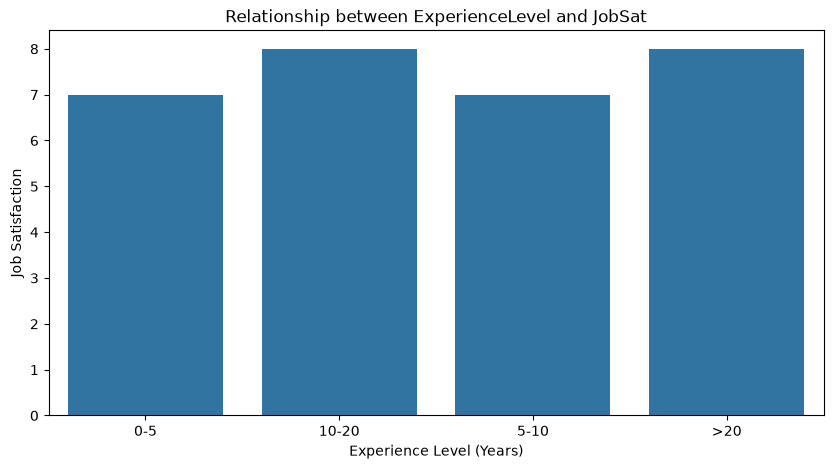

In [7]:
# Create experience ranges for YearsCodePro (e.g., 0-5, 5-10, 10-20, >20 years)
df['YearsCodePro'] = df['YearsCodePro'].replace({"Less than 1 year": "0.5", "More than 50 years": "51"}) #true value will not matter because we will be sorting them into bins
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['ExperienceLevel'] = None
df.loc[df['YearsCodePro'] <= 5, 'ExperienceLevel'] = '0-5'
df.loc[(df['YearsCodePro'] > 5) & (df['YearsCodePro'] <= 10), 'ExperienceLevel'] = '5-10'
df.loc[(df['YearsCodePro'] > 10) & (df['YearsCodePro'] <= 20), 'ExperienceLevel'] = '10-20'
df.loc[df['YearsCodePro'] > 20, 'ExperienceLevel'] = '>20'

# Calculate the median JobSat for each range
b = df.groupby("ExperienceLevel")["JobSat"].median().reset_index()

# Visualize the relationship using a bar plot or similar visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='ExperienceLevel', y='JobSat', data=b)
plt.title("Relationship between ExperienceLevel and JobSat")
plt.xlabel("Experience Level (Years)")
plt.ylabel("Job Satisfaction")
plt.show()

#### Step 5: Visualize Job Satisfaction


Use a count plot to show the distribution of `JobSat` values. This provides insights into the overall satisfaction levels of respondents.


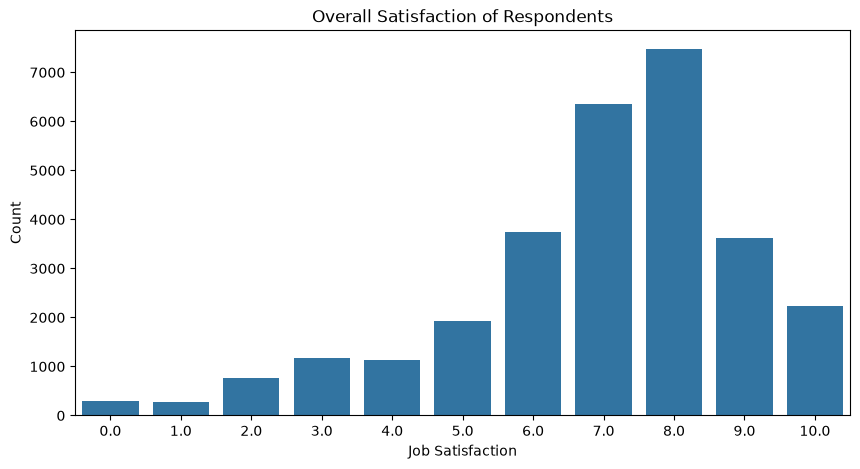

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(x='JobSat', data=df)
plt.title("Overall Satisfaction of Respondents")
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")
plt.show()

#### Step 6: Analyzing Remote Work Preferences by Job Role


Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others.

- Use a count plot to show remote work distribution.

- Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.


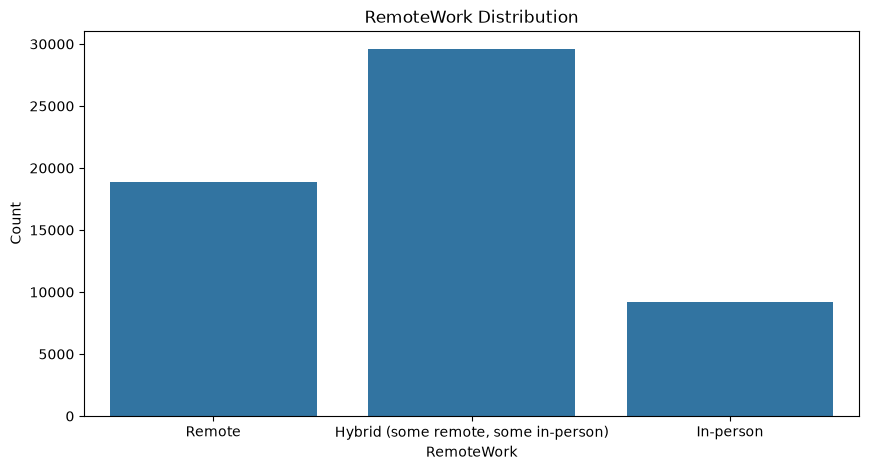

- Frequency Count Table -


RemoteWork                                                            Hybrid (some remote, some in-person)  \
Employment                             DevType                                                               
Employed, full-time                    Academic researcher                                             310   
                                       Blockchain                                                       15   
                                       Cloud infrastructure engineer                                   210   
                                       Data engineer                                                   416   
                                       Data or business analyst                                        170   
...                                                                                                    ...   
Student, part-time;Employed, part-time System administrator                                              3   
Student, part-time;Retired             Developer, full-stack                                             1   
                                       Security professional                                             1   
                                       Student                                                           1   
Total                                                                                                29149   

RemoteWork                                                            In-person  \
Employment                             DevType                                    
Employed, full-time                    Academic researcher                  195   
                                       Blockchain                            13   
                                       Cloud infrastructure engineer         39   
                                       Data engineer                        105   
                                       Data or business analyst              93   
...                                                                         ...   
Student, part-time;Employed, part-time System administrator                   4   
Student, part-time;Retired             Developer, full-stack                  0   
                                       Security professional                  0   
                                       Student                                0   
Total                                                                      9182   

RemoteWork                                                            Remote  \
Employment                             DevType                                 
Employed, full-time                    Academic researcher                38   
                                       Blockchain                         63   
                                       Cloud infrastructure engineer     209   
                                       Data engineer                     291   
                                       Data or business analyst           73   
...                                                                      ...   
Student, part-time;Employed, part-time System administrator                0   
Student, part-time;Retired             Developer, full-stack               0   
                                       Security professional               0   
                                       Student                             0   
Total                                                                  18814   

RemoteWork                                                            Total  
Employment                             DevType                               
Employed, full-time                    Academic researcher              543  
                                       Blockchain                        91  
                                       Cloud infrastructure engineer    458  
                                       Data engineer      

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x='RemoteWork', data=df)
plt.title("RemoteWork Distribution")
plt.xlabel("RemoteWork")
plt.ylabel("Count")
plt.show()

ct = pd.crosstab(
    index=[df['Employment'], df['DevType']], 
    columns=df['RemoteWork'],
    margins=True,            # Adds row and column totals
    margins_name='Total'     # Renames the total row/column
)

# 3. Frequency Count Table
print("- Frequency Count Table -")
ct

#### Step 7: Analyzing Programming Language Trends by Region


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

- Filter data by country or region.

- Visualize the top programming languages by region with a bar plot or heatmap.


        Country SplitColumn  Count
0   Afghanistan  JavaScript     25
1   Afghanistan      Python     25
2   Afghanistan    HTML/CSS     24
3   Afghanistan         SQL     21
4   Afghanistan         PHP     15
49      Albania         SQL     28
50      Albania  JavaScript     26
51      Albania    HTML/CSS     25
52      Albania         PHP     16
53      Albania        Java     16


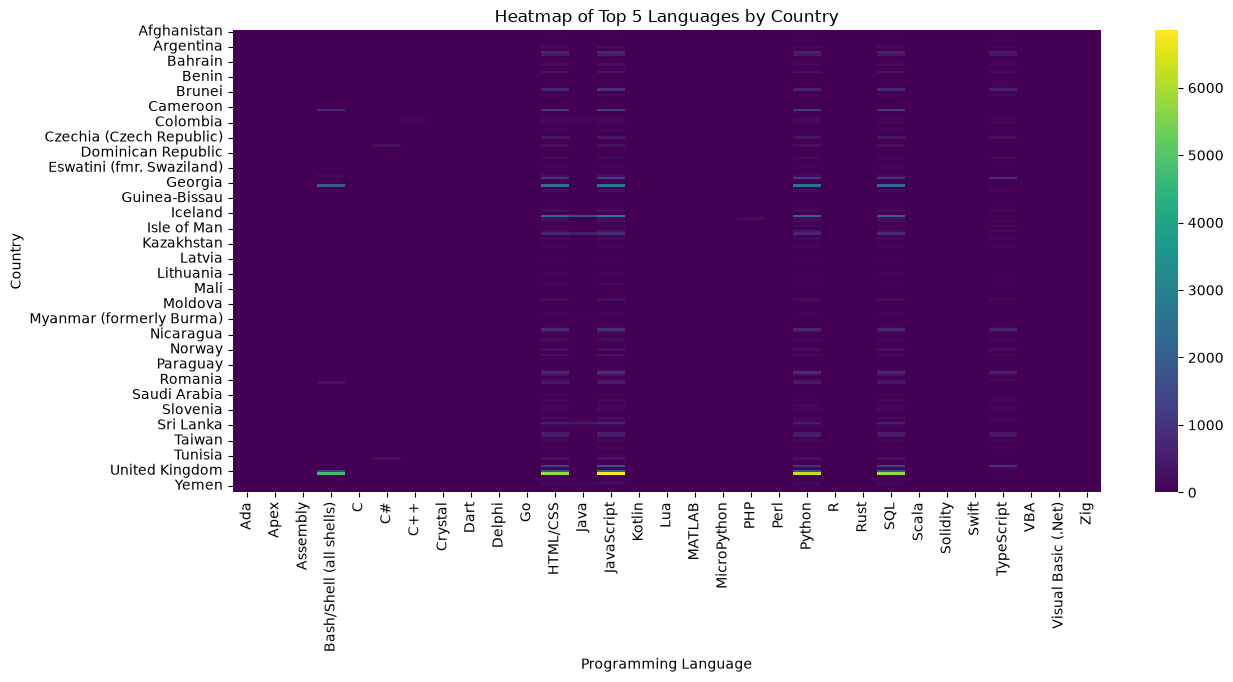

In [10]:
# 1. Split the string values into lists
df['SplitColumn'] = df['LanguageHaveWorkedWith'].str.split(';')

# 2. Explode the lists into individual rows
exploded_df = df.explode('SplitColumn')

# Returns the top 5 occurring programming languages and its count for each country
top_counts = exploded_df.groupby('Country')['SplitColumn'].value_counts().reset_index(name='Count').sort_values(["Country", "Count"], ascending=[True, False]).groupby('Country').head(5)
print (top_counts.head(10))

# Pivot to matrix form for heatmap
heat_table = top_counts.pivot(index="Country", columns="SplitColumn", values="Count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(heat_table, cmap="viridis")
plt.title("Heatmap of Top 5 Languages by Country")
plt.xlabel("Programming Language")
plt.ylabel("Country")
plt.show()

#### Step 8: Correlation Between Experience and Satisfaction


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSatPoints_1`). Use a scatter plot to visualize this relationship.


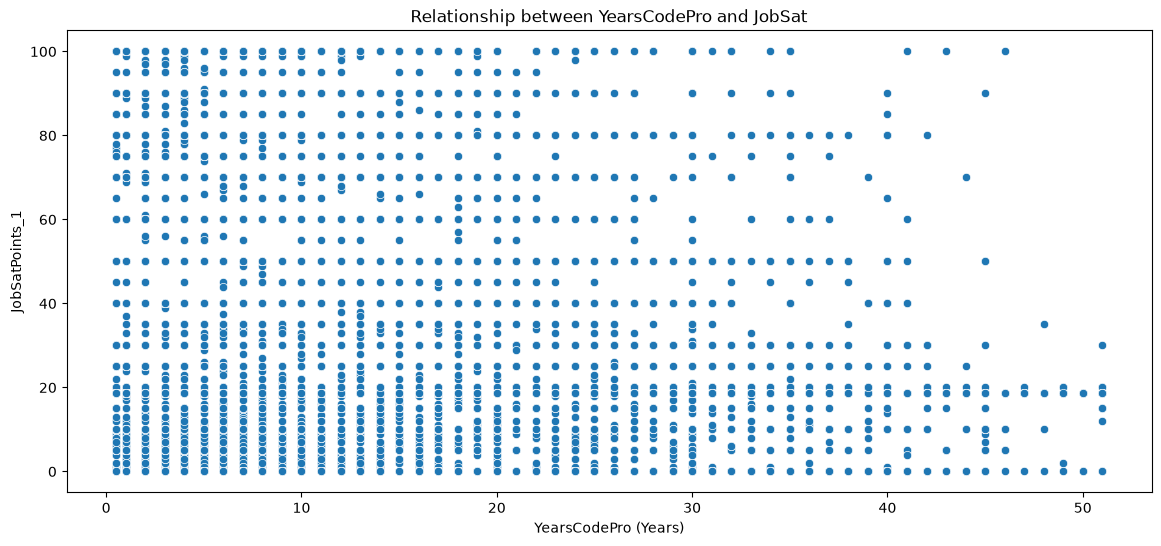

In [11]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x="YearsCodePro", y="JobSatPoints_1")
plt.title("Relationship between YearsCodePro and JobSat")
plt.xlabel("YearsCodePro (Years)")
plt.ylabel("JobSatPoints_1")
plt.show()

#### Step 9: Educational Background and Employment Type


Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.

Employment
Employed, full-time                       34676
Self-employed                              8285
Student, full-time                         4918
Unemployed                                 2553
Employed, part-time                        1049
Student, full-time;Employed, part-time      982
Employed, full-time;Student, full-time      762
Employed, full-time;Student, part-time      728
Student, part-time;Employed, part-time      491
Retired                                     453
Student, part-time                          384
Student, full-time; Self-employed           337
Student, part-time; Self-employed           116
Name: count, dtype: int64
- Frequency Count Table -


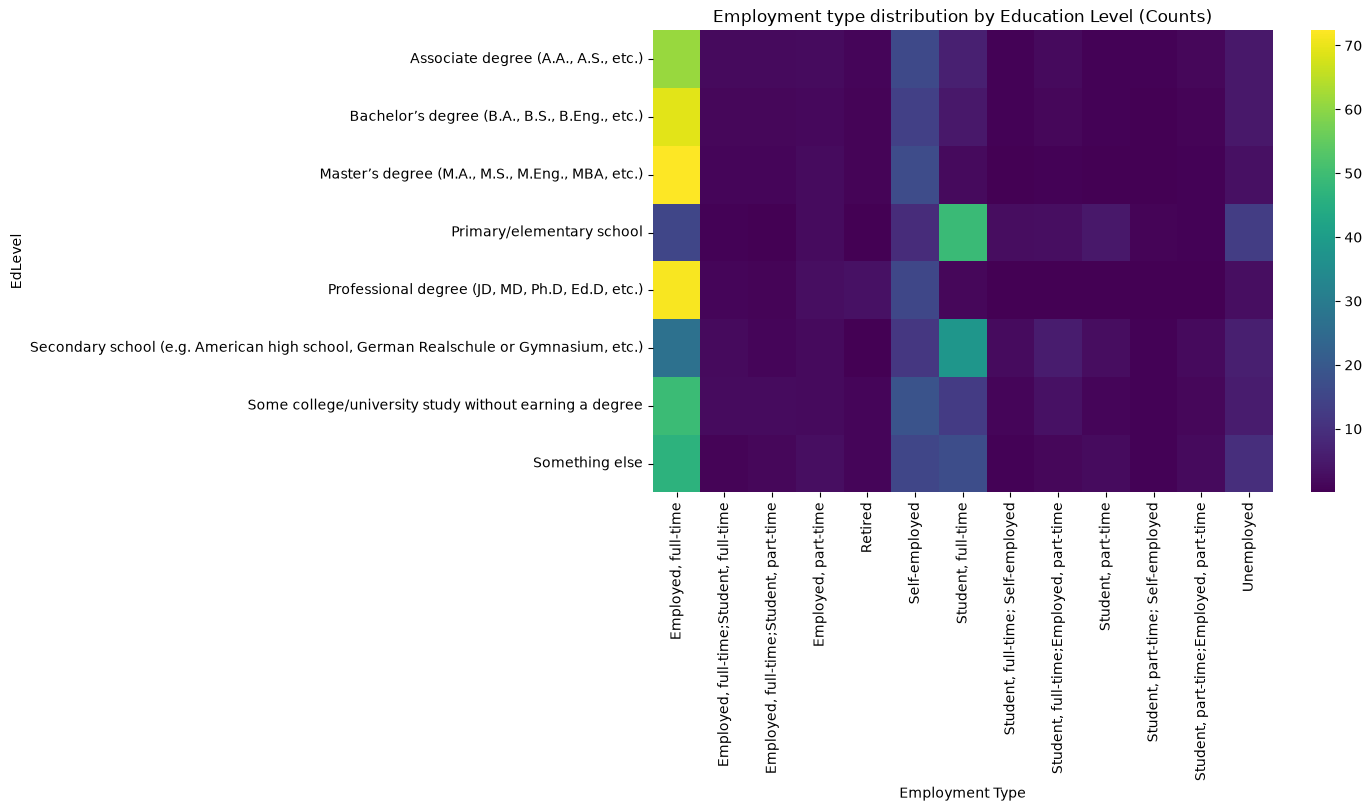

In [74]:
df['Employment'] = df['Employment'].replace({"Independent contractor, freelancer, or self-employed":"Self-employed", 
                                       "Employed, full-time;Independent contractor, freelancer, or self-employed": "Self-employed",
                                      "Not employed, but looking for work": "Unemployed",
                                            "Student, full-time;Not employed, but looking for work": "Student, full-time",
                                            "Not employed, and not looking for work": "Unemployed",
                                            "Not employed, but looking for work;Independent contractor, freelancer, or self-employed": "Self-employed",
"Student, full-time;Not employed, and not looking for work": "Student, full-time",
                                             "Independent contractor, freelancer, or self-employed;Employed, part-time": "Self-employed",
                                             "Student, full-time;Independent contractor, freelancer, or self-employed": "Student, full-time; Self-employed",
                                             "Independent contractor, freelancer, or self-employed;Student, part-time": "Student, part-time; Self-employed"
})

#drop rows with missing values in Employment column
df = df.dropna(subset=['Employment'])

# Drop rows that are "I prefer not to say"
df = df[df['Employment'] != "I prefer not to say"]

# Drop rows if contain both "Employed, full-time" and "Employed, part-time"
# Define conditions to find both strings
emp_full = df['Employment'].str.contains('Employed, full-time', na=False, case=False)
emp_part = df['Employment'].str.contains('Employed, part-time', na=False, case=False)
# Keep only rows that DO NOT contain both strings
df = df[~(emp_full & emp_part)]

# Drop rows if contain both "Student, full-time" and "Student, part-time"
# Define conditions to find both strings
stu_full = df['Employment'].str.contains('Student, full-time', na=False, case=False)
stu_part = df['Employment'].str.contains('Student, part-time', na=False, case=False)
# Keep only rows that DO NOT contain both strings
df = df[~(stu_full & stu_part)]

# Drop rows if string contains "Retired" and string has > 1 phrase
# Define the conditions
has_retired = df['Employment'].str.contains('Retired', na=False, regex=False)
has_multiple_phrases = df['Employment'].str.split(';').str.len() > 1
# Drop the rows that meet both conditions. Combine both conditions with '&', then use '~' to keep all other rows
df = df[~(has_retired & has_multiple_phrases)].reset_index(drop=True)

# Drop rows if contain both ("Employed full-time" or "Employed part-time") and ("Not employed, but looking for work" or "Not employed, and not looking for work")
#Define the conditions
is_looking = df["Employment"].str.contains(
    "Not employed, but looking for work", na=False)
not_looking = df["Employment"].str.contains("Not employed, and not looking for work", na=False)
is_employed = emp_full | emp_part
look = is_looking | not_looking
# Drop rows where both conditions are True
df = df[~(is_employed & look)].reset_index(drop=True)
#Drop rows if "Not employed, but looking for work" and "Not employed, and not looking for work"
df = df[~(look)].reset_index(drop=True)

# drop rows if string contains >=3 phrases
morethan3 = df['Employment'].str.split(';').str.len() >= 3
df = df[~(morethan3)].reset_index(drop=True)

# replace student full time or part time; not working to just student full time or part time
is_student = stu_full | stu_part
df = df[~(look & is_student)].reset_index(drop=True)

print(df['Employment'].value_counts())

#After cleaning data, cross-tabulate results with EdLevel
cross = pd.crosstab(
    index=df['Employment'], 
    columns=df['EdLevel'],
    margins=True,            # Adds row and column totals
    margins_name='Total')     # Renames the total row/column

# Frequency Count Table
print("- Frequency Count Table -")
cross

# cross-tabulate percentages (row-wise)
cross_pct = pd.crosstab(df["EdLevel"], df["Employment"], normalize="index") * 100
cross_pct

plt.figure(figsize=(10,6))
sns.heatmap(cross_pct, cmap="viridis", annot=False)
plt.title("Employment type distribution by Education Level (Counts)")
plt.xlabel("Employment Type")
plt.ylabel("EdLevel")
plt.show()

#### Step 10: Save the Cleaned and Analyzed Dataset


After your analysis, save the modified dataset for further use or sharing.


In [ ]:
df.to_csv('cleanedoutput.csv', index=False)

<h2>Summary</h2>


In this revised lab, you:

- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.


Copyright © IBM Corporation. All rights reserved.
